# Transfer Learning con Keras 3

Entrenar redes neuronales convolucionales (CNNs) puede tomar mucho tiempo y requiere grandes cantidades de datos. Sin embargo, gran parte de ese tiempo se dedica a aprender filtros de bajo nivel que una red utiliza para extraer patrones de las imágenes.

Surge entonces una pregunta natural: **¿podemos usar una red neuronal entrenada en un conjunto de datos y adaptarla para clasificar imágenes diferentes sin entrenar todo desde cero?**

A este enfoque se le llama **aprendizaje por transferencia (transfer learning)**. Normalmente partimos de un modelo preentrenado sobre un conjunto grande, como ImageNet. Ese modelo ya ha aprendido características visuales generales —bordes, texturas, formas y patrones— y podemos reutilizarlas para una nueva tarea.

> En este notebook usaremos **Keras 3** con backend TensorFlow.

In [1]:
# IMPORTANTE: definir el backend antes de importar keras.
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image
import zipfile
import glob

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))

Keras: 3.13.2
TensorFlow: 2.20.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Conjunto de datos de Gatos vs. Perros

Resolveremos un problema de clasificación binaria: distinguir imágenes de **gatos** y **perros**.

Usaremos el conjunto de datos *Cats vs. Dogs*, originalmente publicado en Kaggle y distribuido también por Microsoft. Lo descargaremos en el directorio `data/`.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

zip_path = keras.utils.get_file(
    fname="kagglecatsanddogs_5340.zip",
    origin=url,
    cache_dir=".",
    cache_subdir="data",
)

zip_path = Path(zip_path)
print("Archivo:", zip_path)

824887076/824887076 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Archivo: data/kagglecatsanddogs_5340.zip


In [3]:
extract_dir = Path("data")
pet_dir = extract_dir / "PetImages"

if not pet_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

print("Dataset:", pet_dir)

Dataset: data/PetImages


### Limpieza de imágenes corruptas

Este conjunto contiene algunas imágenes corruptas. Antes de construir el dataset verificaremos los archivos y eliminaremos únicamente aquellos que no puedan abrirse correctamente.

En PyTorch el notebook original delegaba esta tarea a una utilidad externa. Aquí la implementamos directamente con Pillow para que el notebook no dependa de `pytorchcv`.

In [4]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*"):
        if path.suffix.lower() not in [
            ".jpg", ".jpeg", ".png", ".bmp", ".gif"
        ]:
            continue

        try:
            raw = tf.io.read_file(str(path))
            tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False
            )

        except Exception:
            bad_files.append(path)

    for path in bad_files:
        print("Eliminando:", path)
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

remove_invalid_images("data/PetImages")

Eliminando: data/PetImages/Cat/10404.jpg
Eliminando: data/PetImages/Cat/4351.jpg
Eliminando: data/PetImages/Cat/666.jpg
Eliminando: data/PetImages/Dog/2317.jpg
Eliminando: data/PetImages/Dog/9500.jpg
Eliminando: data/PetImages/Dog/11702.jpg
Eliminando: data/PetImages/Dog/11233.jpg
Eliminando: data/PetImages/Dog/2494.jpg
Eliminando: data/PetImages/Dog/11912.jpg

Imágenes inválidas eliminadas: 9


In [5]:
import tensorflow as tf

root = Path("data/PetImages")

bad_files = []

for path in root.rglob("*"):
    if path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".gif"]:
        continue

    try:
        raw = tf.io.read_file(str(path))
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    except Exception as e:
        print("ERROR:", path)
        print(e)
        print("-" * 80)
        bad_files.append(path)

print("Archivos problemáticos:", len(bad_files))

Archivos problemáticos: 0


## Carga de imágenes con Keras 3

En Keras podemos construir directamente un `tf.data.Dataset` desde una estructura de carpetas:

```text
PetImages/
├── Cat/
└── Dog/
```

Usaremos imágenes de `224×224`, que es el tamaño estándar de entrada de VGG16.

No normalizaremos manualmente con media y desviación estándar. Cada arquitectura preentrenada de Keras Applications proporciona su propia función `preprocess_input`, que aplica exactamente el preprocesamiento esperado por los pesos de ImageNet.

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = keras.utils.image_dataset_from_directory(
    "data/PetImages",
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

test_ds = keras.utils.image_dataset_from_directory(
    "data/PetImages",
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_ds.class_names
print("Clases:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.
Clases: ['Cat', 'Dog']


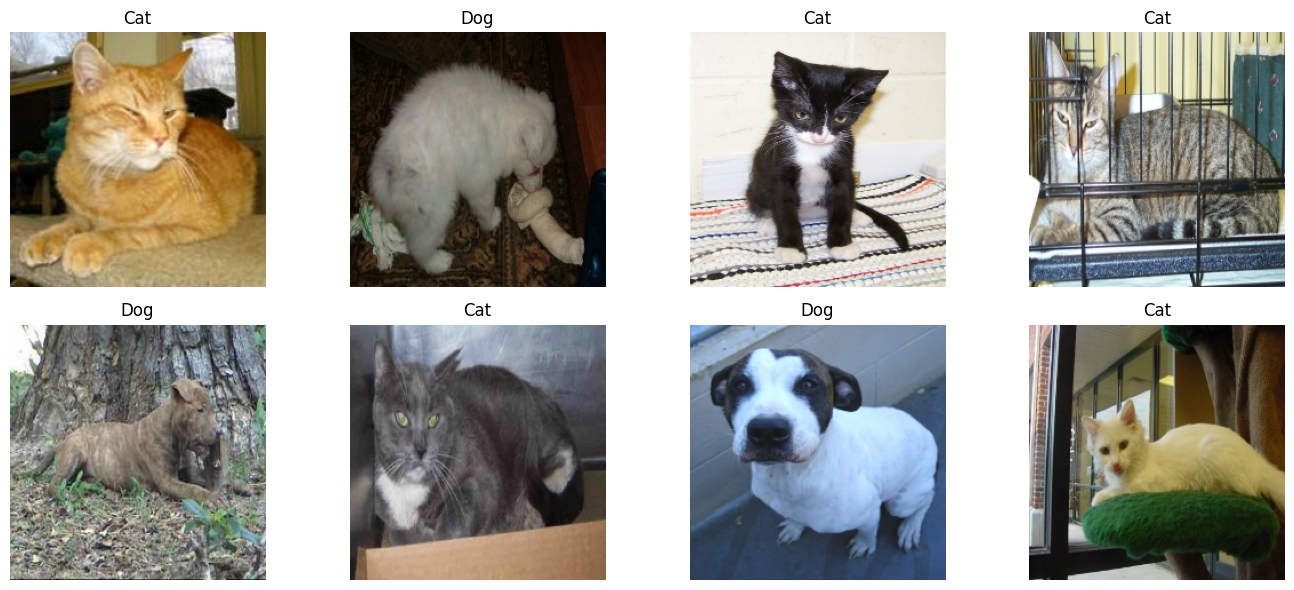

In [7]:
def display_dataset(dataset, class_names, n=8):
    images, labels = next(iter(dataset))

    plt.figure(figsize=(14, 6))
    for i in range(min(n, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.tight_layout()

display_dataset(train_ds, class_names)

## Modelos preentrenados

Keras incluye múltiples arquitecturas preentrenadas mediante `keras.applications`.

Comenzaremos con **VGG16** y sus pesos entrenados sobre ImageNet.

In [8]:
vgg_imagenet = keras.applications.VGG16(
    weights="imagenet",
    include_top=True,
)

images, labels = next(iter(train_ds))
sample_image = images[:1]

x = keras.applications.vgg16.preprocess_input(sample_image)
pred = vgg_imagenet(x, training=False)

print("Índice de la clase con mayor probabilidad:", int(tf.argmax(pred[0])))

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Índice de la clase con mayor probabilidad: 208


El resultado anterior es un índice correspondiente a una de las 1000 clases de ImageNet. En Keras no necesitamos descargar manualmente una tabla externa: podemos decodificar las predicciones con `decode_predictions`.

In [9]:
top3 = keras.applications.vgg16.decode_predictions(pred.numpy(), top=3)[0]

for imagenet_id, label, probability in top3:
    print(f"{label:25s} {probability:.4f}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Labrador_retriever        0.7573
Chesapeake_Bay_retriever  0.0403
American_Staffordshire_terrier 0.0238


### Arquitectura de VGG16

`Model.summary()` muestra directamente las capas, dimensiones y número de parámetros. No necesitamos instalar `torchsummary`.

In [10]:
vgg_imagenet.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Cálculos en GPU

Con Keras + TensorFlow **no es necesario mover manualmente el modelo y cada tensor a `cuda`**. TensorFlow selecciona automáticamente la GPU para las operaciones compatibles cuando existe una disponible.

Podemos comprobar los dispositivos detectados:

In [11]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("Keras/TensorFlow puede usar GPU:", gpus)
else:
    print("No se detectó GPU; el notebook se ejecutará en CPU.")

Keras/TensorFlow puede usar GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Extracción de características con VGG16

Para utilizar VGG16 como **extractor de características**, cargamos la red con `include_top=False`. Esto elimina el clasificador original de ImageNet y conserva únicamente la parte convolucional.

Para una entrada `224×224×3`, VGG16 produce un tensor de características de tamaño `7×7×512`.

In [12]:
feature_extractor = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3),
)

sample_preprocessed = keras.applications.vgg16.preprocess_input(sample_image)
features = feature_extractor(sample_preprocessed, training=False)

print("Shape:", features.shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape: (1, 7, 7, 512)


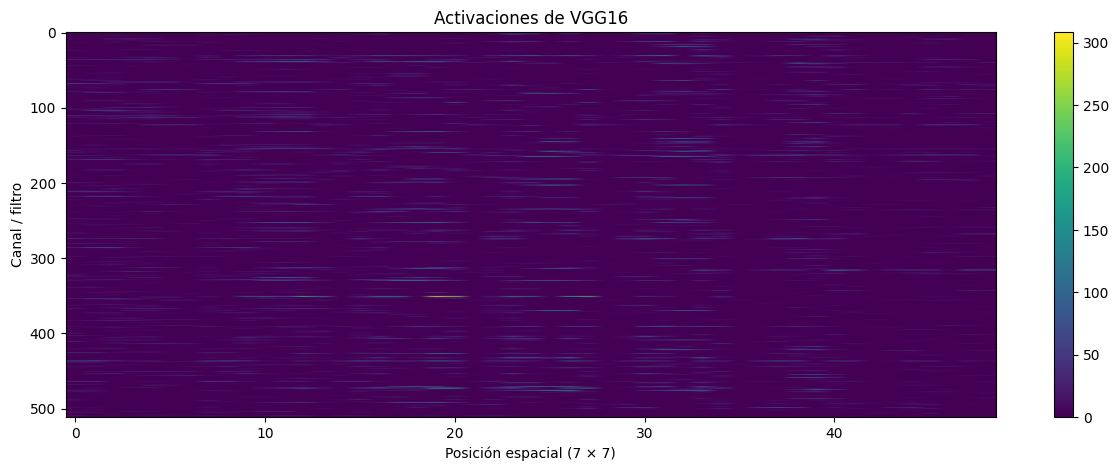

In [13]:
feature_map = features[0].numpy()          # (7, 7, 512)
feature_map_2d = feature_map.reshape(-1, feature_map.shape[-1]).T  # (512, 49)

plt.figure(figsize=(15, 5))
plt.imshow(feature_map_2d, aspect="auto")
plt.xlabel("Posición espacial (7 × 7)")
plt.ylabel("Canal / filtro")
plt.title("Activaciones de VGG16")
plt.colorbar()
plt.show()

La salida tiene 512 mapas de características sobre una rejilla espacial `7×7`. Para visualizarla la reorganizamos como una matriz `512×49`.

Ahora comprobaremos si esas características sirven para separar gatos y perros. Tomaremos **800 imágenes**, calcularemos sus representaciones con VGG16 una sola vez y entrenaremos sobre ellas un clasificador denso muy pequeño.

In [14]:
NUM_FEATURE_SAMPLES = 800

small_ds = (
    train_ds
    .unbatch()
    .shuffle(5000, seed=SEED)
    .take(NUM_FEATURE_SAMPLES)
    .batch(32)
)

feature_batches = []
label_batches = []

for images, labels in small_ds:
    images = keras.applications.vgg16.preprocess_input(images)
    f = feature_extractor(images, training=False)
    f = tf.reshape(f, [tf.shape(f)[0], -1])

    feature_batches.append(f)
    label_batches.append(labels)

X_features = tf.concat(feature_batches, axis=0)
y_features = tf.concat(label_batches, axis=0)

print("X:", X_features.shape)
print("y:", y_features.shape)

X: (800, 25088)
y: (800,)


Dividimos esas 800 representaciones en 700 ejemplos para entrenamiento y 100 para prueba, y usamos una única capa `Dense(2)` como clasificador.

In [15]:
X_train, X_test = X_features[:700], X_features[700:800]
y_train, y_test = y_features[:700], y_features[700:800]

feature_classifier = keras.Sequential([
    keras.Input(shape=(512 * 7 * 7,)),
    layers.Dense(2, activation="softmax"),
], name="feature_classifier")

feature_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_features = feature_classifier.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8686 - loss: 4.6119 - val_accuracy: 0.9700 - val_loss: 0.9096
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9857 - loss: 0.3037 - val_accuracy: 0.9500 - val_loss: 0.9506
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9971 - loss: 0.0364 - val_accuracy: 0.9500 - val_loss: 1.4255
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.4060e-10 - val_accuracy: 0.9500 - val_loss: 1.5934
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 4.2575e-09 - val_accuracy: 0.9500 - val_loss: 1.6123


Este experimento ilustra la idea central: **el modelo preentrenado transforma las imágenes en características útiles y nosotros aprendemos únicamente una nueva frontera de decisión**.

Sin embargo, no es necesario precalcular manualmente las características. Podemos construir un solo modelo que contenga el extractor VGG16 congelado y un clasificador nuevo.

## Transfer learning con VGG16

Construiremos el modelo en tres partes:

1. `preprocess_input` adapta las imágenes al formato esperado por VGG16.
2. `base_model` contiene la parte convolucional preentrenada y permanece congelada.
3. Una nueva capa `Dense(2)` aprende nuestra tarea gatos vs. perros.

Aquí reemplazamos **todo el clasificador original de ImageNet**, no únicamente su última neurona de salida. De este modo quedan aproximadamente 50 mil parámetros entrenables, que corresponde al escenario descrito conceptualmente en el notebook.

In [16]:
base_model = keras.applications.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMAGE_SIZE, 3),
)

base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
x = keras.applications.vgg16.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.Flatten(name="flatten")(x)
outputs = layers.Dense(2, activation="softmax", name="classifier")(x)

model = keras.Model(inputs, outputs, name="cats_vs_dogs_vgg16")

model.summary()

print(f"Parámetros totales:      {model.count_params():,}")
print(
    "Parámetros entrenables:",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

Model: "cats_vs_dogs_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 2)         │     50,178 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Parámetros totales:      14,764,866
Parámetros entrenables: 50,178


Con el extractor congelado, los gradientes solo actualizan la nueva capa de clasificación. Esto permite adaptar el modelo con pocos datos y reduce considerablemente el costo del backward pass.

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_transfer = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1,
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 250ms/step - accuracy: 0.9694 - loss: 1.5257 - val_accuracy: 0.9774 - val_loss: 1.5395


### Guardar el modelo

El formato recomendado de Keras guarda arquitectura, pesos y configuración del modelo en un único archivo `.keras`.

In [18]:
Path("data").mkdir(exist_ok=True)

model.save("data/cats_dogs.keras")
print("Modelo guardado en data/cats_dogs.keras")

Modelo guardado en data/cats_dogs.keras


También podemos guardar **solo los pesos**, que es el concepto más cercano a guardar un `state_dict` en PyTorch.

En Keras:

```python
model.save_weights("data/cats_dogs.weights.h5")
```

Para recuperar únicamente esos pesos debemos recrear una arquitectura compatible y llamar `load_weights`.

In [19]:
model.save_weights("data/cats_dogs.weights.h5")

# Opción 1: cargar el modelo completo.
loaded_model = keras.models.load_model("data/cats_dogs.keras")

# Opción 2: si recreamos exactamente la misma arquitectura:
# model.load_weights("data/cats_dogs.weights.h5")

print("Modelo cargado:", loaded_model.name)

Modelo cargado: cats_vs_dogs_vgg16


## Ajuste fino (*fine-tuning*)

Hasta ahora entrenamos únicamente el clasificador nuevo. El extractor de VGG16 sigue usando exactamente las características aprendidas con ImageNet.

En *fine-tuning* descongelamos una parte de la red preentrenada y continuamos entrenando con una **tasa de aprendizaje muy pequeña**.

La secuencia recomendada es:

1. congelar la base preentrenada;
2. entrenar primero el clasificador nuevo;
3. descongelar únicamente las capas superiores que queremos adaptar;
4. **recompilar** el modelo;
5. continuar el entrenamiento con un `learning_rate` pequeño.

No conviene empezar directamente con toda la red descongelada porque las actualizaciones iniciales del clasificador aleatorio pueden alterar agresivamente los pesos preentrenados.

In [20]:
# Descongelamos la base...
base_model.trainable = True

# ...pero dejamos congelados todos los bloques excepto block5.
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("block5")

trainable_base_layers = [layer.name for layer in base_model.layers if layer.trainable]

print("Capas entrenables de VGG16:")
for name in trainable_base_layers:
    print(" -", name)

Capas entrenables de VGG16:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool


Después de cambiar la propiedad `trainable`, debemos **recompilar** el modelo para que Keras reconstruya el conjunto de variables que el optimizador actualizará.

Durante fine-tuning usamos un `learning_rate` mucho menor que el empleado para entrenar inicialmente el clasificador.

In [21]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()

Model: "cats_vs_dogs_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ image[0][0]       │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 2)         │     50,178 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 7,129,602 (27.20 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [22]:
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1,
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 168s 257ms/step - accuracy: 0.9911 - loss: 0.3625 - val_accuracy: 0.9862 - val_loss: 0.6380


> **Nota sobre Batch Normalization:** VGG16 no contiene capas Batch Normalization, pero otras arquitecturas sí. En modelos con BatchNorm suele ser importante ejecutar la base con `training=False` durante transfer learning/fine-tuning para no modificar accidentalmente sus estadísticas internas. Por eso construimos el modelo con `base_model(x, training=False)`.

## Otros modelos de visión por computador

Keras Applications incluye otras familias preentrenadas como **ResNet**, **Inception**, **MobileNet**, **EfficientNet**, **DenseNet**, entre otras.

El paquete base de Keras Applications no incluye ResNet18. Para mantener este notebook sin dependencias adicionales, utilizaremos **ResNet50** como ejemplo de la familia ResNet.

In [23]:
resnet = keras.applications.ResNet50(
    weights=None,
    include_top=True,
    classes=1000,
)

resnet.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

Al igual que VGG16, ResNet puede utilizarse como extractor de características con `include_top=False` y luego conectarse a un nuevo clasificador.

Una diferencia importante es que ResNet contiene capas de **Batch Normalization** y conexiones residuales. Para transfer learning se aplica el mismo patrón general:

```python
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model.trainable = False
```

Después se agrega la cabeza de clasificación específica para la nueva tarea.

## Normalización por lotes (Batch Normalization)

Batch Normalization normaliza las activaciones intermedias utilizando estadísticas calculadas durante el entrenamiento y mantiene estadísticas móviles para inferencia. Esto ayuda a estabilizar el proceso de optimización de redes profundas.

En un flujo de transfer learning debemos tratar estas capas con cuidado porque sus estadísticas forman parte del conocimiento aprendido durante el preentrenamiento.

## Conclusión

Usando aprendizaje por transferencia podemos construir rápidamente un clasificador para una tarea personalizada reutilizando representaciones visuales aprendidas previamente.

En Keras 3 el flujo puede resumirse así:

1. cargar un modelo de `keras.applications` con pesos de ImageNet;
2. remover su clasificador con `include_top=False`;
3. congelar el modelo base con `trainable = False`;
4. agregar una nueva cabeza de clasificación;
5. entrenar la cabeza;
6. opcionalmente descongelar los últimos bloques y hacer *fine-tuning* con una tasa de aprendizaje pequeña.

En este ejemplo VGG16 ya ha visto categorías relacionadas con gatos y perros durante su preentrenamiento en ImageNet, por lo que la transferencia es especialmente favorable. En dominios más alejados de ImageNet —por ejemplo imágenes médicas, industriales o satelitales— puede ser necesario adaptar una porción mayor de la red y validar cuidadosamente el beneficio del fine-tuning.